Загрузка статей с arXiv...
Загружено 60 статей из категории math.CO
Загружено 120 статей из категории math.ST
Загружено 180 статей из категории math.LO
Загружено 240 статей из категории math.OA
Загружено 300 статей из категории math.PR
Загружено 300 статей
Извлечение ключевых слов...
Построение графа ключевых слов...
Граф содержит 532 узлов и 5439 ребер
Кластеризация ключевых слов...
Найдено 11 кластеров
Модулярность кластеризации: 0.347

Кластеры ключевых слов:
Кластер 1 (65 слов): ['quasi', 'parallel', 'extremal', 'explicit', 'part']...
Кластер 2 (39 слов): ['approximate', 'hilbert', 'loss', 'transfer', 'systems']...
Кластер 3 (46 слов): ['bounded', 'computational', 'threshold', 'mu_', 'triangulations']...
Кластер 4 (9 слов): ['omega', 'prec', 'linear', 'delta_', 'balancing']...
Кластер 5 (24 слов): ['sample', 'structures', 'examples', 'banach', 'inference']...
Кластер 6 (74 слов): ['optimal', 'tests', 'estimator', 'bayes', 'coefficient']...
Кластер 7 (53 слов): ['flows', 'cycle', 'g

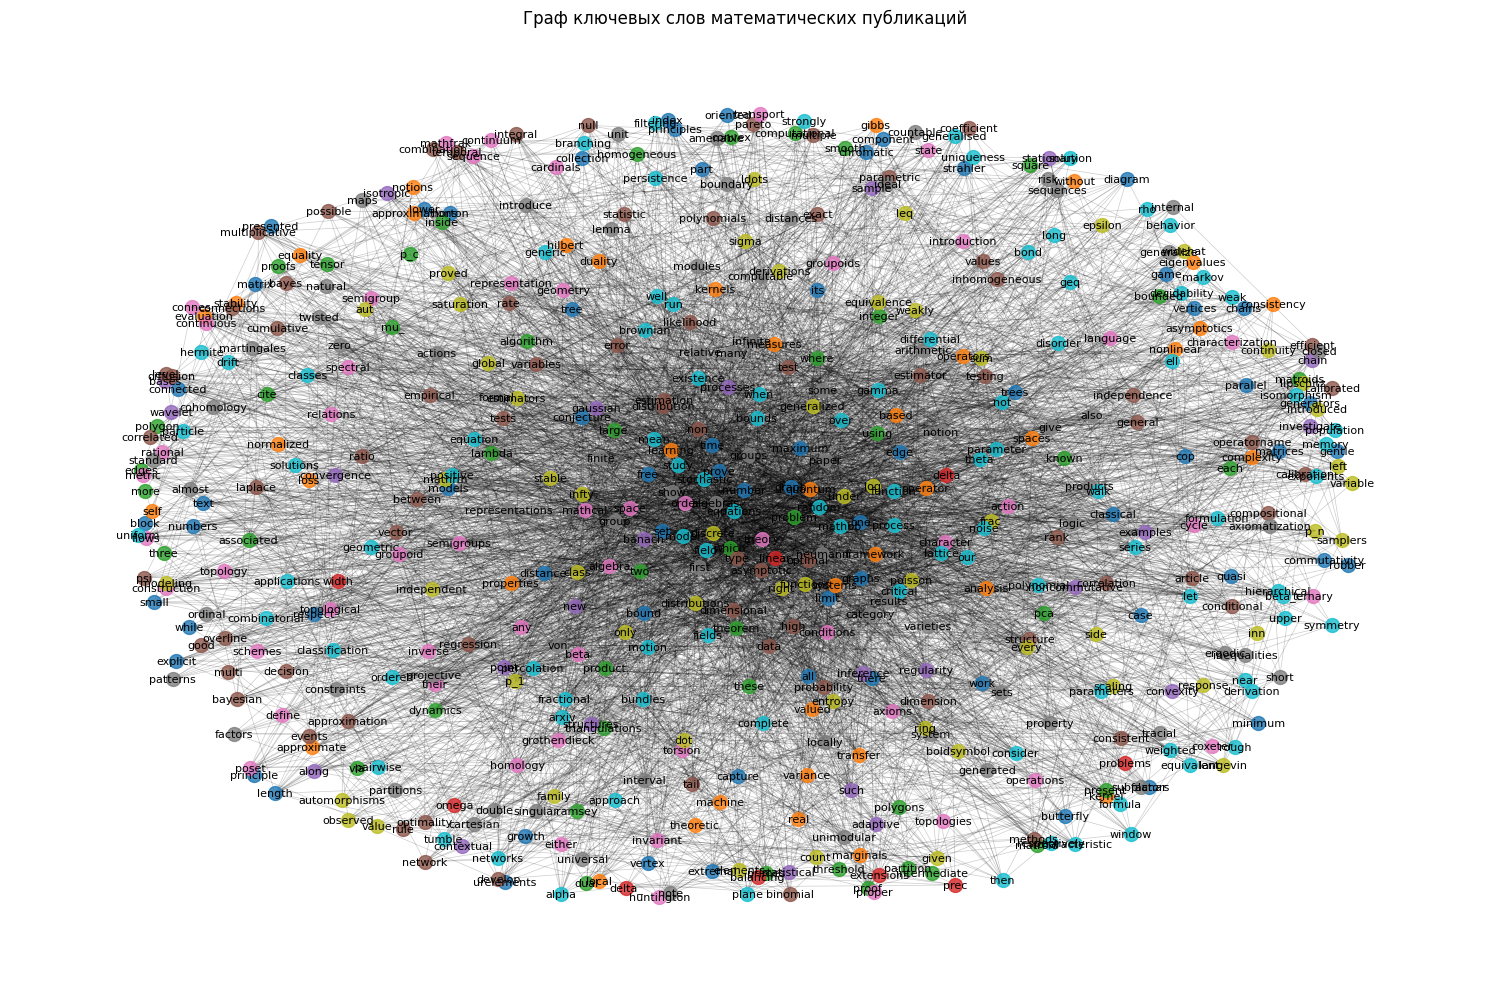

In [1]:
import requests
import xml.etree.ElementTree as ET
import time
import re
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np

# 1) Выбор тематики - Mathematics с подтемами
SUBJECTS = {
    'math.CO': 'Combinatorics',
    'math.ST': 'Statistics Theory', 
    'math.LO': 'Logic',
    'math.OA': 'Operator Algebras',
    'math.PR': 'Probability'
}

# 2) Скачивание данных с arXiv API
def fetch_arxiv_papers(subjects, max_results=300):
    """
    Загружает статьи с arXiv по указанным категориям
    """
    base_url = "http://export.arxiv.org/api/query?"
    papers = []
    
    for category in subjects:
        query = f"search_query=cat:{category}&max_results={max_results}&sortBy=submittedDate&sortOrder=descending"
        url = base_url + query
        
        try:
            response = requests.get(url)
            response.raise_for_status()
            
            # Парсинг XML
            root = ET.fromstring(response.content)
            namespace = '{http://www.w3.org/2005/Atom}'
            
            for entry in root.findall(f'.//{namespace}entry'):
                paper = {
                    'id': entry.find(f'{namespace}id').text if entry.find(f'{namespace}id') is not None else '',
                    'title': entry.find(f'{namespace}title').text.strip() if entry.find(f'{namespace}title') is not None else '',
                    'summary': entry.find(f'{namespace}summary').text.strip() if entry.find(f'{namespace}summary') is not None else '',
                    'authors': [author.find(f'{namespace}name').text for author in entry.findall(f'{namespace}author')],
                    'categories': [cat.attrib.get('term', '') for cat in entry.findall(f'{namespace}category')],
                    'published': entry.find(f'{namespace}published').text if entry.find(f'{namespace}published') is not None else ''
                }
                papers.append(paper)
            
            print(f"Загружено {len(papers)} статей из категории {category}")
            time.sleep(1)  # Пауза между запросами
            
        except Exception as e:
            print(f"Ошибка при загрузке категории {category}: {e}")
    
    return papers

# 3) Извлечение ключевых слов
def extract_keywords(text, max_words=10):
    """
    Извлекает ключевые слова из текста
    """
    if not text:
        return []
    
    # Очистка текста
    text = re.sub(r'[^\w\s]', ' ', text.lower())
    words = text.split()
    
    # Удаление стоп-слов
    stop_words = {'the', 'and', 'of', 'in', 'to', 'a', 'an', 'for', 'on', 'with', 
                 'by', 'as', 'at', 'from', 'that', 'this', 'is', 'are', 'was', 'were',
                 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did',
                 'will', 'would', 'could', 'should', 'may', 'might', 'must', 'can'}
    
    # Фильтрация и подсчет
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
    word_counts = Counter(filtered_words)
    
    # Возвращаем наиболее частые слова
    return [word for word, count in word_counts.most_common(max_words)]

def process_papers_for_keywords(papers):
    """
    Обрабатывает статьи и извлекает ключевые слова
    """
    for paper in papers:
        combined_text = paper['title'] + ' ' + paper['summary']
        paper['keywords'] = extract_keywords(combined_text)
    
    return papers

# 4) Построение графа ключевых слов
def build_keyword_graph(papers, min_cooccurrence=2):
    """
    Строит граф связей между ключевыми словами
    """
    G = nx.Graph()
    keyword_papers = {}  # Словарь: ключевое слово -> список статей
    
    # Собираем информацию о ключевых словах
    for paper in papers:
        for keyword in paper['keywords']:
            if keyword not in keyword_papers:
                keyword_papers[keyword] = []
            keyword_papers[keyword].append(paper['id'])
    
    # Добавляем узлы (ключевые слова)
    for keyword, paper_list in keyword_papers.items():
        if len(paper_list) >= min_cooccurrence:  # Только слова, встречающиеся хотя бы в 2 статьях
            G.add_node(keyword, weight=len(paper_list))
    
    # Добавляем ребра (связи между словами)
    for i, (kw1, papers1) in enumerate(keyword_papers.items()):
        if kw1 not in G:
            continue
            
        for j, (kw2, papers2) in enumerate(keyword_papers.items()):
            if i >= j or kw2 not in G:
                continue
                
            # Находим общие статьи
            common_papers = set(papers1) & set(papers2)
            if common_papers:
                weight = len(common_papers)
                G.add_edge(kw1, kw2, weight=weight)
    
    return G

# 5) Кластеризация и оценка качества
def cluster_keywords(G):
    """
    Кластеризует ключевые слова и оценивает качество
    """
    # Используем алгоритм Лувена для сообществ
    communities = nx.community.louvain_communities(G, weight='weight', seed=42)
    
    # Присваиваем кластеры узлам
    for cluster_id, community in enumerate(communities):
        for node in community:
            G.nodes[node]['cluster'] = cluster_id
    
    # Оценка качества кластеризации (модулярность)
    modularity = nx.community.modularity(G, communities, weight='weight')
    
    return communities, modularity

def visualize_graph(G, communities):
    """
    Визуализирует граф с кластерами
    """
    plt.figure(figsize=(15, 10))
    
    # Позиционирование узлов
    pos = nx.spring_layout(G, k=1, iterations=50, seed=42)
    
    # Рисуем узлы по кластерам
    colors = plt.cm.tab10(np.linspace(0, 1, len(communities)))
    
    for i, community in enumerate(communities):
        nx.draw_networkx_nodes(G, pos, nodelist=list(community), 
                              node_color=[colors[i]], 
                              node_size=100, alpha=0.8)
    
    # Рисуем ребра
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)
    
    # Подписи только для важных узлов
    important_nodes = [node for node, degree in dict(G.degree()).items() if degree > 5]
    labels = {node: node for node in important_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    
    plt.title("Граф ключевых слов математических публикаций")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Основная функция
def main():
    print("Загрузка статей с arXiv...")
    papers = fetch_arxiv_papers(SUBJECTS.keys(), max_results=60)  # 60 на категорию = 300 всего
    
    print(f"Загружено {len(papers)} статей")
    
    print("Извлечение ключевых слов...")
    papers = process_papers_for_keywords(papers)
    
    print("Построение графа ключевых слов...")
    keyword_graph = build_keyword_graph(papers)
    
    print(f"Граф содержит {keyword_graph.number_of_nodes()} узлов и {keyword_graph.number_of_edges()} ребер")
    
    print("Кластеризация ключевых слов...")
    communities, modularity = cluster_keywords(keyword_graph)
    
    print(f"Найдено {len(communities)} кластеров")
    print(f"Модулярность кластеризации: {modularity:.3f}")
    
    # Вывод информации о кластерах
    print("\nКластеры ключевых слов:")
    for i, community in enumerate(communities):
        print(f"Кластер {i+1} ({len(community)} слов): {list(community)[:5]}...")
    
    # Визуализация
    print("\nВизуализация графа...")
    visualize_graph(keyword_graph, communities)
    
    return papers, keyword_graph, communities, modularity

if __name__ == "__main__":
    papers, graph, communities, modularity = main()